# Tehran House Price Prediction

Machine learning regression project for predicting residential property prices in Tehran.

## 1. Import Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

## 2. Load Dataset

In [2]:
df = pd.read_csv("housePrice.csv")
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


## 3. Data Understanding

In [3]:
df.shape

(3479, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   str    
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   str    
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), str(2)
memory usage: 146.2 KB


In [5]:
df.isna().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [6]:
df["Area"].describe()

count     3479
unique     243
top         75
freq       111
Name: Area, dtype: object

In [7]:
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")

In [8]:
df["Area"].describe()

count    3473.000000
mean      106.774547
std        69.365567
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max       929.000000
Name: Area, dtype: float64

In [9]:
df[df["Area"].isna()]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
570,NaN,2,True,True,True,Ostad Moein,3.310000e+09,110333.33
709,NaN,3,True,True,True,Pasdaran,1.616000e+10,538666.67
807,NaN,2,True,True,False,Damavand,7.000000e+09,233333.33
1604,NaN,2,True,True,True,Gheitarieh,8.700000e+09,290000.00
2171,NaN,2,False,False,False,Shahryar,9.720000e+09,324000.00
2802,NaN,2,True,True,True,Central Janatabad,2.550000e+09,85000.00


In [10]:
df = df.dropna(subset=["Area"])

In [11]:
df = df.dropna(subset=["Address"])

In [12]:
df.shape

(3450, 8)

In [15]:
df.describe()

,Area,Room,Price,Price(USD)
count,3450.000000,3450.000000,3.450000e+03,3.450000e+03
mean,106.917391,2.081159,5.375563e+09,1.791854e+05
std,69.550976,0.760216,8.125918e+09,2.708639e+05
min,30.000000,0.000000,3.600000e+06,1.200000e+02
25%,69.000000,2.000000,1.419250e+09,4.730833e+04
50%,90.000000,2.000000,2.900000e+09,9.666667e+04
75%,120.000000,2.000000,6.000000e+09,2.000000e+05
max,929.000000,5.000000,9.240000e+10,3.080000e+06


In [16]:
df.nlargest(10, "Area")[["Area", "Address", "Price"]]

,Area,Address,Price
1694,929.0,Zafar,8.000000e+10
1974,900.0,Damavand,8.500000e+09
573,863.0,Gheitarieh,7.830000e+09
831,750.0,Mahmoudieh,7.500000e+10
3115,750.0,Varamin - Beheshti,3.500000e+09
1810,705.0,Abazar,9.100000e+10
2481,700.0,Damavand,4.500000e+09
2647,700.0,Damavand,7.000000e+09
819,680.0,Ekhtiarieh,8.160000e+10
431,660.0,Lavasan,5.500000e+10


In [17]:
df["Area"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    170.0
0.950    210.0
0.990    400.0
0.995    500.0
0.999    750.0
Name: Area, dtype: float64

In [18]:
df = df[df["Area"] <= 500]

In [19]:
df.shape

(3433, 8)

In [20]:
df.describe()

,Area,Room,Price,Price(USD)
count,3433.000000,3433.000000,3.433000e+03,3.433000e+03
mean,104.018060,2.074279,5.212296e+09,1.737432e+05
std,55.595229,0.748359,7.404752e+09,2.468251e+05
min,30.000000,0.000000,3.600000e+06,1.200000e+02
25%,68.000000,2.000000,1.400000e+09,4.666667e+04
50%,90.000000,2.000000,2.850000e+09,9.500000e+04
75%,120.000000,2.000000,6.000000e+09,2.000000e+05
max,500.000000,5.000000,9.240000e+10,3.080000e+06


In [21]:
df["Address"].nunique(), df["Room"].value_counts()

(191,
 Room
 2    1934
 3     726
 1     669
 4      69
 5      26
 0       9
 Name: count, dtype: int64)

In [22]:
df[["Parking", "Warehouse", "Elevator"]].apply(pd.Series.value_counts)

,Parking,Warehouse,Elevator
True,2909,3142,2713
False,524,291,720


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 3433 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3433 non-null   float64
 1   Room        3433 non-null   int64  
 2   Parking     3433 non-null   bool   
 3   Warehouse   3433 non-null   bool   
 4   Elevator    3433 non-null   bool   
 5   Address     3433 non-null   str    
 6   Price       3433 non-null   float64
 7   Price(USD)  3433 non-null   float64
dtypes: bool(3), float64(3), int64(1), str(1)
memory usage: 171.0 KB


In [25]:
df = df.reset_index(drop=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3433 entries, 0 to 3432
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3433 non-null   float64
 1   Room        3433 non-null   int64  
 2   Parking     3433 non-null   bool   
 3   Warehouse   3433 non-null   bool   
 4   Elevator    3433 non-null   bool   
 5   Address     3433 non-null   str    
 6   Price       3433 non-null   float64
 7   Price(USD)  3433 non-null   float64
dtypes: bool(3), float64(3), int64(1), str(1)
memory usage: 144.3 KB


## 4. Exploratory Data Analysis

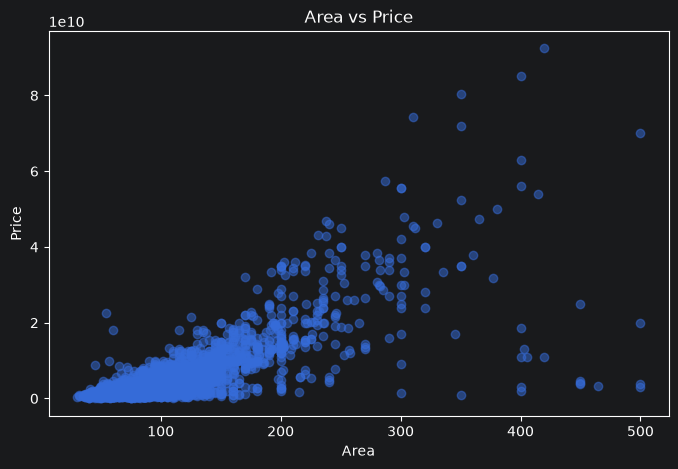

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Area"], df["Price"], alpha=0.5)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

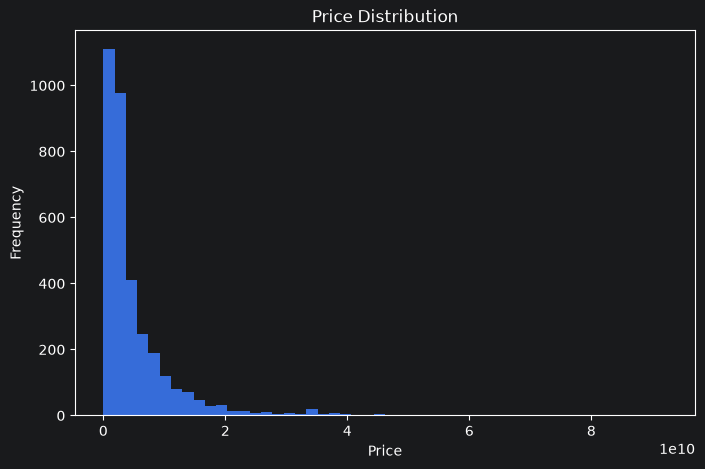

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

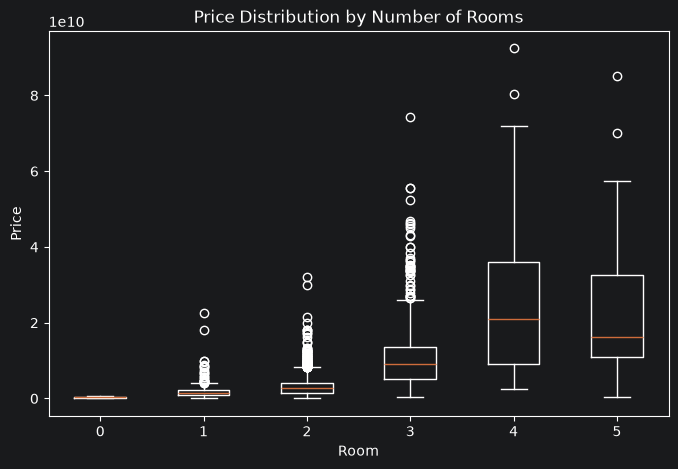

In [30]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df.loc[df["Room"] == room, "Price"] for room in sorted(df["Room"].unique())],
    tick_labels=sorted(df["Room"].unique())
)
plt.xlabel("Room")
plt.ylabel("Price")
plt.title("Price Distribution by Number of Rooms")
plt.show()

In [31]:
df.groupby("Address")["Price"].median().sort_values(ascending=False).head(10)

Address
Gandhi        7.000000e+10
Vanak         3.270000e+10
Elahieh       3.166800e+10
Lavasan       2.700000e+10
Argentina     2.516500e+10
Farmanieh     2.000000e+10
Zaferanieh    1.800000e+10
Niavaran      1.690000e+10
Kamranieh     1.550000e+10
Velenjak      1.497250e+10
Name: Price, dtype: float64

In [32]:
df.groupby("Parking")["Price"].median()

Parking
False    9.400000e+08
True     3.330000e+09
Name: Price, dtype: float64

In [33]:
df.groupby("Warehouse")["Price"].median()

Warehouse
False    1.100000e+09
True     3.050000e+09
Name: Price, dtype: float64

In [34]:
df.groupby("Elevator")["Price"].median()

Elevator
False    1.450000e+09
True     3.400000e+09
Name: Price, dtype: float64

In [35]:
df[["Area", "Room", "Price"]].corr()

,Area,Room,Price
Area,1.000000,0.758738,0.764829
Room,0.758738,1.000000,0.573376
Price,0.764829,0.573376,1.000000


## 5. Feature Engineering

In [36]:
df["Address"].nunique()

191

### 5.1 Feature Selection

In [37]:
X = df.drop(["Price", "Price(USD)"], axis=1)
y = df["Price(USD)"]

### 5.2 Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
X_train.shape, X_test.shape

((2746, 6), (687, 6))

### 5.3 Address Encoding

The `Address` feature contains categorical location information with 191 unique areas.
To convert this categorical feature into a meaningful numerical representation, the areas
will be ranked based on their median house price.

The median price of each area is calculated using only the training data to prevent data leakage.
Areas are then ordered from lower-priced to higher-priced and assigned numerical values based
on this order. The same mapping will be applied to the test data.

In [41]:
address_price = pd.DataFrame({
    "Address": X_train["Address"],
    "Price": y_train
})

address_median = address_price.groupby("Address")["Price"].median().sort_values()

address_median.head()

Address
Malard          8333.33
Pishva         10000.00
Parand         13233.33
Shahedshahr    14033.33
Firoozkooh     15666.67
Name: Price, dtype: float64

In [42]:
address_mapping = {
    address: rank
    for rank, address in enumerate(address_median.index)
}

In [43]:
X_train["Address"] = X_train["Address"].map(address_mapping)
X_test["Address"] = X_test["Address"].map(address_mapping)

In [44]:
X_train.dtypes

Area         float64
Room           int64
Parking         bool
Warehouse       bool
Elevator        bool
Address        int64
dtype: object

In [48]:
X_test["Address"].isna().sum()

np.int64(0)

Some addresses in the test set were not present in the training set. Therefore, their corresponding numerical encoding could not be obtained and resulted in missing values.

Instead of removing these samples, the median encoded value from the training set is used as a default value for unseen addresses. This allows the model to retain all test samples while avoiding the use of information from the test set.

In [46]:
address_default = int(np.median(list(address_mapping.values())))

X_test["Address"] = X_test["Address"].fillna(address_default)

In [49]:
X_test["Address"].isna().sum()

np.int64(0)

## 6. Data Preprocessing

In [50]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 2746 entries, 1536 to 3174
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2746 non-null   float64
 1   Room       2746 non-null   int64  
 2   Parking    2746 non-null   bool   
 3   Warehouse  2746 non-null   bool   
 4   Elevator   2746 non-null   bool   
 5   Address    2746 non-null   int64  
dtypes: bool(3), float64(1), int64(2)
memory usage: 93.9 KB


In [51]:
for col in ["Parking", "Warehouse", "Elevator"]:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

In [52]:
X_train.dtypes

Area         float64
Room           int64
Parking        int64
Warehouse      int64
Elevator       int64
Address        int64
dtype: object

### 6.1 Feature Scaling

Standardization will be applied to the numerical features for models that are sensitive to feature scale.
Tree-based models will be trained without scaling.

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Model Training

### 7.1 Linear Regression

In [57]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[167375.01,-12431.44,-18407.53, 4721.5 , 2759.44, 85437.46]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.735e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[83.72,60.35,46.39,41.43,35.94,25.78]"


In [58]:
y_pred_linear = linear_model.predict(X_test_scaled)

### 7.2 Ridge Regression

In [76]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [64]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

### 7.3 Decision Tree Regression

In [80]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with

In [81]:
y_pred_tree = tree_model.predict(X_test)

### 7.4 Random Forest Regression

In [84]:
forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [85]:
y_pred_forest = forest_model.predict(X_test)

### 7.5 Gradient Boosting Regression

In [88]:
gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [89]:
y_pred_gradient = gradient_model.predict(X_test)

### 7.6 XGBoost Regression

In [95]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
y_pred_xgb = xgb_model.predict(X_test)

## 8. Model Evaluation

### 8.1 Linear Regression

In [60]:
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 66488.19
RMSE: 125564.55
R²: 0.6876


### 8.2 Ridge Regression

In [77]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE: {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²: {r2_ridge:.4f}")

MAE: 66482.09
RMSE: 125557.77
R²: 0.6876


### 8.3 Decision Tree Regression

In [82]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print(f"MAE: {mae_tree:.2f}")
print(f"RMSE: {rmse_tree:.2f}")
print(f"R²: {r2_tree:.4f}")

MAE: 45811.30
RMSE: 128404.81
R²: 0.6733


### 8.4 Random Forest Regression

In [86]:
mae_forest = mean_absolute_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
r2_forest = r2_score(y_test, y_pred_forest)

print(f"MAE: {mae_forest:.2f}")
print(f"RMSE: {rmse_forest:.2f}")
print(f"R²: {r2_forest:.4f}")

MAE: 36852.28
RMSE: 90769.54
R²: 0.8368


### 8.5 Gradient Boosting Regression

In [90]:
mae_gradient = mean_absolute_error(y_test, y_pred_gradient)
rmse_gradient = np.sqrt(mean_squared_error(y_test, y_pred_gradient))
r2_gradient = r2_score(y_test, y_pred_gradient)

print(f"MAE: {mae_gradient:.2f}")
print(f"RMSE: {rmse_gradient:.2f}")
print(f"R²: {r2_gradient:.4f}")

MAE: 39722.63
RMSE: 92851.23
R²: 0.8292


### 8.6 XGBoost Regression

In [97]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²: {r2_xgb:.4f}")

MAE: 36048.36
RMSE: 85978.05
R²: 0.8535


### 8.7 Model Comparison

In [99]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_ridge,
        mae_tree,
        mae_forest,
        mae_gradient,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_ridge,
        rmse_tree,
        rmse_forest,
        rmse_gradient,
        rmse_xgb
    ],
    "R²": [
        r2,
        r2_ridge,
        r2_tree,
        r2_forest,
        r2_gradient,
        r2_xgb
    ]
})

results.sort_values("R²", ascending=False).reset_index(drop=True)

,Model,MAE,RMSE,R²
0,XGBoost,36048.360590,85978.048375,0.853532
1,Random Forest,36852.280367,90769.538611,0.836752
2,Gradient Boosting,39722.630143,92851.234312,0.829178
3,Ridge Regression,66482.089198,125557.766927,0.687641
4,Linear Regression,66488.191307,125564.552940,0.687607
5,Decision Tree,45811.296692,128404.810508,0.673314


## 9. Feature Importance

### 9.1 XGBoost Feature Importance

In [101]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance", ascending=False
)

feature_importance

,Feature,Importance
0,Area,0.552996
5,Address,0.307430
1,Room,0.063694
4,Elevator,0.045302
2,Parking,0.021606
3,Warehouse,0.008971


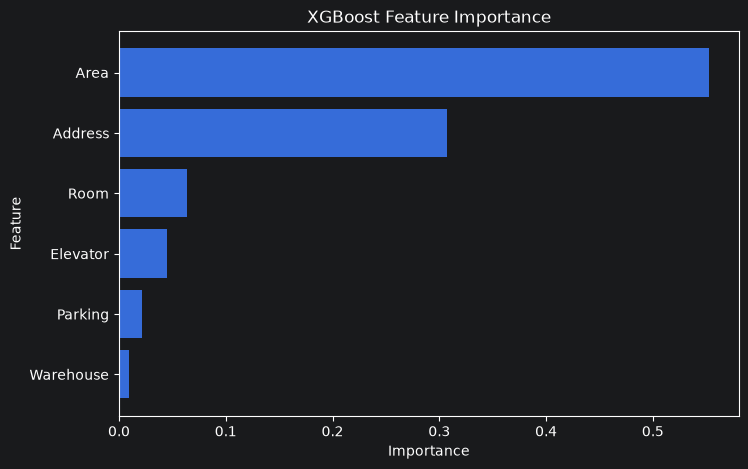

In [102]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

## 10. Prediction Analysis

### 10.1 Actual vs Predicted Prices

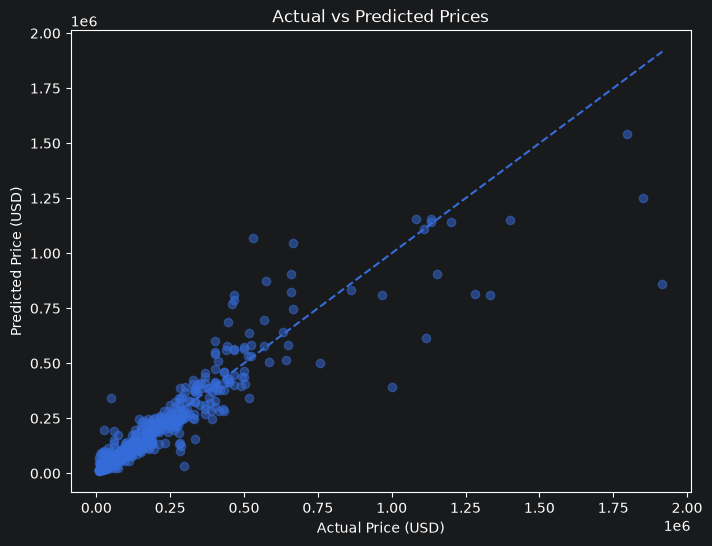

In [104]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### 10.2 Residual Analysis

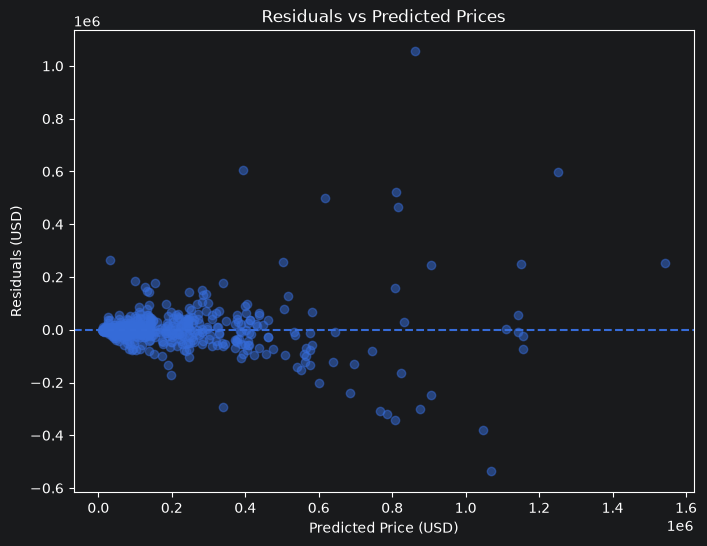

In [106]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_xgb, residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residuals (USD)")
plt.title("Residuals vs Predicted Prices")

plt.show()

In [107]:
print("Mean Residual:", residuals.mean())
print("Residual Std:", residuals.std())
print("Maximum Absolute Error:", np.abs(residuals).max())

Mean Residual: 1519.230444527839
Residual Std: 86027.25855561152
Maximum Absolute Error: 1054651.2325


## 11. Conclusion

This project developed a machine learning regression model for predicting residential property prices in Tehran.

After data cleaning and preprocessing, several regression models were trained and evaluated. Among the tested models, XGBoost achieved the best overall performance with an R² score of 0.854, an MAE of approximately $36,048, and an RMSE of approximately $85,978.

Feature importance analysis showed that Area and Address were the most influential features, highlighting the importance of both property size and location in predicting house prices.

Residual analysis showed that prediction errors were generally smaller for lower-priced properties and increased for higher-priced properties. This indicates that the model performs better on typical lower-priced properties but has more difficulty predicting extreme high-value properties.